In [45]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
data = pd.read_csv('raw_sales.csv')
data.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [47]:
df = data.copy()
df = df.rename(columns={'datesold': 'date', 'propertyType': 'type'})
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,postcode,price,type,bedrooms
0,2007-02-07,2607,525000,house,4
1,2007-02-27,2906,290000,house,3
2,2007-03-07,2905,328000,house,3
3,2007-03-09,2905,380000,house,4
4,2007-03-21,2906,310000,house,3


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      29580 non-null  datetime64[us]
 1   postcode  29580 non-null  int64         
 2   price     29580 non-null  int64         
 3   type      29580 non-null  str           
 4   bedrooms  29580 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(1)
memory usage: 1.1 MB


type
house    647956.128462
unit     423106.557279
Name: price, dtype: float64


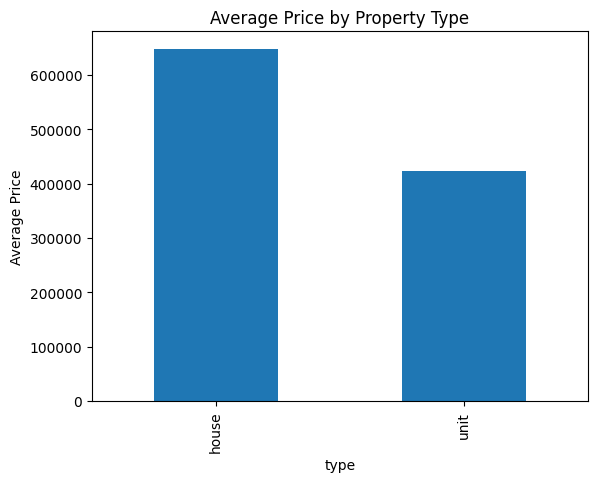

In [49]:
avg_price_by_type = df.groupby('type')['price'].mean().sort_values(ascending=False)
print(avg_price_by_type)
avg_price_by_type.plot(kind='bar', title='Average Price by Property Type')
plt.ylabel('Average Price')
plt.show()

bedrooms
5    919056.058974
4    718171.142023
3    552304.428140
0    542300.000000
2    442222.917454
1    335992.905962
Name: price, dtype: float64


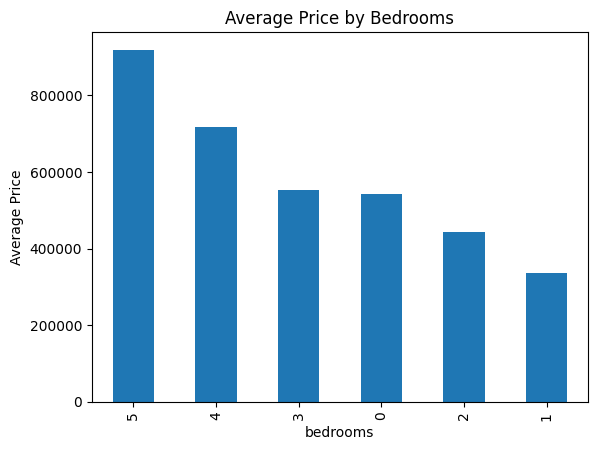

In [50]:
avg_price_by_bedrooms = df.groupby('bedrooms')['price'].mean().sort_values(ascending=False)
print(avg_price_by_bedrooms)

avg_price_by_bedrooms.plot(kind='bar', title='Average Price by Bedrooms')
plt.ylabel('Average Price')
plt.show()

The number of bedrooms 0 can be considered as missing values, as it is unlikely that a property would have zero bedrooms. It is possible that these entries were either not recorded correctly. To handle these missing values, we can either impute them with a reasonable value (such as the median number of bedrooms for that property type) or we can choose to drop those rows from the dataset if they are not significant in number.

In [51]:
# KNNImputer

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

df['bedrooms'] = df['bedrooms'].replace(0,np.nan)

le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])

features = ['price', 'type_encoded', 'bedrooms']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

imputer = KNNImputer(n_neighbors=5, weights='distance')
X_imputed = imputer.fit_transform(X_scaled)
X_unscaled = scaler.inverse_transform(X_imputed)
df['bedrooms'] = X_unscaled[:,2]

df['bedrooms'] = df['bedrooms'].round().astype(int)
df['bedrooms'] = df['bedrooms'].clip(lower=1, upper=5)
df['bedrooms'].value_counts()

bedrooms
3    11941
4    10453
2     3602
5     1950
1     1634
Name: count, dtype: int64

In [52]:
#print the different values that bedrooms assumes when type == 'unit'
print(df[df['type'] == 'unit']['bedrooms'].unique())

[2 3 1 4 5]
